In [24]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
import sys

sys.path.insert(1,"../src/")

from utilities import find_peaks, wideband_pulse
import warping

In [26]:
from visualization_tools import SelectFromCollection

In [27]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
import scipy.signal as sp
from scipy.ndimage import label

from matplotlib.widgets import Button

In [28]:
%matplotlib widget

In [29]:
# [Title, Freq, ssp, bdry, pos, beam, cint, rmax] = at.read_env("feif_scenario.env", "KRAKEN")

In [30]:
SAMPLING_FREQ = 2000
TRUE_SOUNDSPEED = 1460

#NPERSEG = 200
WINDOW = sp.windows.hann

NPEAKS = 20

In [31]:
wb_pulse_params = dict(pulse_duration=0.1, fs=SAMPLING_FREQ, bw=200, fc=350, window=sp.windows.hann)

In [32]:
data1 =  scipy.io.loadmat("../data/components_time_series/rts_10km_mca.mat")
x0 = data1['x0'].flatten()
y = data1['y']

In [33]:
replica1 = scipy.io.loadmat("../data/field_values20260707/field_values20260707.mat")

In [34]:
Vg = replica1['Vg'][:,:,replica1['soundspeed'].squeeze() == TRUE_SOUNDSPEED,...].squeeze()
f_vg = replica1['f'][0, 1:-1]
sensor_range = replica1['range'][0,0] * 1e3
t0 = sensor_range/1500

replica_arrival_times = sensor_range/Vg

In [35]:
stft1_short_window = sp.ShortTimeFFT.from_window(
    'hamming', SAMPLING_FREQ, 80, 80-1, mfft = 2000)

stft1_long_window = sp.ShortTimeFFT.from_window(
        'hamming', SAMPLING_FREQ, 200, 200-1, mfft = 2000)

In [36]:
fmask = np.all(np.array([stft1_short_window.f>=200, stft1_short_window.f<=500]), axis=0)

w = stft1_short_window.f[fmask]

In [37]:
t_short = stft1_short_window.t(len(x0)) + t0
t_long = stft1_long_window.t(len(x0)) + t0

In [38]:
t_short

array([6.64716667, 6.64766667, 6.64816667, ..., 7.68516667, 7.68566667,
       7.68616667], shape=(2079,))

## Full Signal

In [39]:
X0_short = stft1_short_window.stft( np.real(x0.squeeze()))[fmask,:]
X0_long = stft1_long_window.stft( np.real(x0.squeeze()))[fmask,:]

In [40]:
peaksx_short = find_peaks(np.abs(X0_short)**2, w, t_short, 17)
peaksx_long = find_peaks(np.abs(X0_long)**2, w, t_long, 17)

In [51]:
fig, ax = plt.subplots(2,1, layout = 'constrained')

m1 = ax[0].pcolormesh(t_short, w, 10*np.log10(np.abs(X0_short)**2))
ax[0].scatter(peaksx_short[:,0], peaksx_short[:,1])

m1 = ax[1].pcolormesh(t_long, w, 10*np.log10(np.abs(X0_long)**2))
ax[1].scatter(peaksx_long[:,0], peaksx_long[:,1])

fig.colorbar(m1, ax=ax)

## Components

In [52]:
Y_short = stft1_short_window.stft(np.real(y.mT))[:,fmask,:]
Y_long = stft1_long_window.stft(np.real(y.mT))[:,fmask,:]

In [53]:
peaksy_short = list()

min_peak_height = np.quantile(np.abs(Y_short)**2, 0.9)
for Ynow in Y_short[:,::10,:]:
    peaksy_short.append(find_peaks(np.abs(Ynow)**2, w[::10], t_short, 10, min_height=min_peak_height))

In [54]:
peaksy_long= list()

min_peak_height = np.quantile(np.abs(Y_long)**2, 0.9)
for Ynow in Y_long[:,::10,:]:
    peaksy_long.append(find_peaks(np.abs(Ynow)**2, w[::10], t_long, 10, min_height=min_peak_height))

(6.666666666666667, 7.666666666666667)

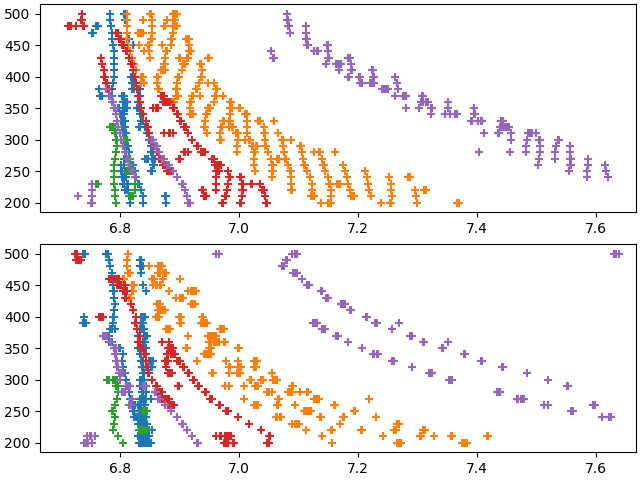

In [55]:
fig, (ax_short, ax_long) = plt.subplots(2,1, layout = 'constrained')

#ax_short.plot(replica_arrival_times.mT, f_vg)

for p in peaksy_short:
    ax_short.scatter(p[:,0], p[:,1], marker = '+', )
ax_short.set_xlim([t0, t0+1])

#ax_long.plot(replica_arrival_times.mT, f_vg)
for p in peaksy_long:
    pts = ax_long.scatter(p[:,0], p[:,1], marker = '+', )
ax_long.set_xlim([t0, t0+1])


In [56]:
classified_peaks = list()

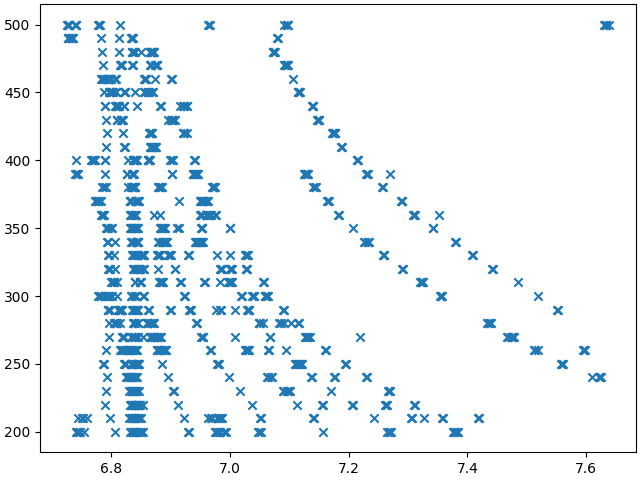

In [81]:
fig, ax = plt.subplots(layout = 'constrained')

p = np.concatenate(peaksy_long)

points = ax.scatter(p[:,0], p[:,1], marker = 'x')
    
selector = SelectFromCollection(ax, points)

In [82]:
selector.disconnect()

classified_peaks.append(selector.xys[selector.ind])

In [83]:
plt.close('all')

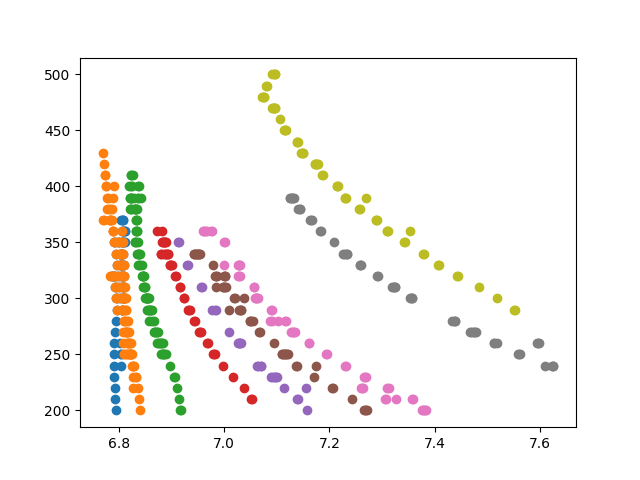

In [84]:
fig, ax = plt.subplots()

for p in classified_peaks:
    ax.scatter(p[:,0], p[:,1])